<a href="https://colab.research.google.com/github/PeterykSong/DeepLearning_Tutorial/blob/main/assets/notebooks/fastslam_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import numpy as np
from dataclasses import dataclass, field

@dataclass
class Landmark:
    mu: np.ndarray        # shape: (2,) landmark position [x, y]
    sigma: np.ndarray     # shape: (2, 2) covariance
    observed: bool = False

@dataclass
class Particle:
    pose: np.ndarray      # shape: (3,) [x, y, theta]
    weight: float
    landmarks: dict = field(default_factory=dict)

@dataclass
class Control:
    v: float              # linear velocity
    w: float              # angular velocity

In [37]:
def normalize_angle(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


def motion_model(pose, control, dt, noise_std):
    x, y, theta = pose
    v = control.v + np.random.randn() * noise_std[0]
    w = control.w + np.random.randn() * noise_std[1]

    x_new = x + v * dt * np.cos(theta)
    y_new = y + v * dt * np.sin(theta)
    theta_new = theta + w * dt
    theta_new = normalize_angle(theta_new)

    return np.array([x_new, y_new, theta_new])

In [53]:
# def initialize_particles(num_particles, init_pose):
#     particles = []

#     for _ in range(num_particles):
#         p = Particle(
#             pose=init_pose.copy(),
#             weight=1.0 / num_particles,
#             landmarks={}
#         )
#         particles.append(p)

#     return particles

def initialize_particles(num_particles, init_pose):

    particles = []

    for _ in range(num_particles):

        pose = np.array([
            init_pose[0] + np.random.randn()*0.5,
            init_pose[1] + np.random.randn()*0.5,
            init_pose[2] + np.random.randn()*0.1
        ])

        particles.append(
            Particle(
                pose=pose,
                weight=1.0/num_particles,
                landmarks={}
            )
        )

    return particles

In [39]:
def predict_particles(particles, control, dt, motion_noise):
    for p in particles:
        p.pose = motion_model(
            pose=p.pose,
            control=control,
            dt=dt,
            noise_std=motion_noise
        )

In [40]:
# z = [range, bearing, landmark_id]

def observation_model(pose, landmark_mu):
    x, y, theta = pose
    mx, my = landmark_mu

    dx = mx - x
    dy = my - y

    r = np.sqrt(dx**2 + dy**2)
    bearing = np.arctan2(dy, dx) - theta
    bearing = normalize_angle(bearing)

    return np.array([r, bearing])

In [41]:
# r, bearing, landmark_id
def initialize_landmark(particle, measurement, measurement_noise):
    r, bearing, landmark_id = measurement
    x, y, theta = particle.pose

    mx = x + r * np.cos(theta + bearing)
    my = y + r * np.sin(theta + bearing)

    mu = np.array([mx, my])

    sigma = np.eye(2) * 1.0

    particle.landmarks[int(landmark_id)] = Landmark(
        mu=mu,
        sigma=sigma,
        observed=True
    )


In [42]:
def update_particles_with_observations(particles, measurements, measurement_noise):
    for p in particles:
        for z in measurements:
            r, bearing, landmark_id = z
            landmark_id = int(landmark_id)

            if landmark_id not in p.landmarks:
                initialize_landmark(p, z, measurement_noise)
            else:
                update_landmark_ekf(p, z, measurement_noise)

In [43]:
def compute_jacobian(pose, landmark_mu):
    x, y, theta = pose
    mx, my = landmark_mu

    dx = mx - x
    dy = my - y

    q = dx**2 + dy**2
    sqrt_q = np.sqrt(q)

    H = np.array([
        [dx / sqrt_q, dy / sqrt_q],
        [-dy / q,      dx / q]
    ])

    return H

In [44]:
def measurement_likelihood(innovation, S):
    dim = len(innovation)

    det_S = np.linalg.det(S)
    inv_S = np.linalg.inv(S)

    norm_const = 1.0 / np.sqrt((2 * np.pi) ** dim * det_S)
    exponent = -0.5 * innovation.T @ inv_S @ innovation

    return norm_const * np.exp(exponent)

In [45]:
def update_landmark_ekf(particle, measurement, measurement_noise):
    r, bearing, landmark_id = measurement
    landmark_id = int(landmark_id)

    landmark = particle.landmarks[landmark_id]

    z = np.array([r, bearing])

    z_hat = observation_model(particle.pose, landmark.mu)

    innovation = z - z_hat
    innovation[1] = normalize_angle(innovation[1])

    H = compute_jacobian(particle.pose, landmark.mu)

    R = measurement_noise

    S = H @ landmark.sigma @ H.T + R

    K = landmark.sigma @ H.T @ np.linalg.inv(S)

    landmark.mu = landmark.mu + K @ innovation

    I = np.eye(2)
    landmark.sigma = (I - K @ H) @ landmark.sigma

    likelihood = measurement_likelihood(innovation, S)

    particle.weight *= likelihood

In [46]:
def normalize_weights(particles):
    total_weight = sum(p.weight for p in particles)

    if total_weight == 0:
        n = len(particles)
        for p in particles:
            p.weight = 1.0 / n
        return

    for p in particles:
        p.weight /= total_weight

In [47]:
def resample_particles(particles):
    n = len(particles)

    weights = np.array([p.weight for p in particles])
    indices = np.random.choice(
        np.arange(n),
        size=n,
        replace=True,
        p=weights
    )

    new_particles = []

    for idx in indices:
        old_p = particles[idx]

        new_p = Particle(
            pose=old_p.pose.copy(),
            weight=1.0 / n,
            landmarks={
                lm_id: Landmark(
                    mu=lm.mu.copy(),
                    sigma=lm.sigma.copy(),
                    observed=lm.observed
                )
                for lm_id, lm in old_p.landmarks.items()
            }
        )

        new_particles.append(new_p)

    return new_particles

In [48]:
def fastslam_step(particles,control,measurements,dt,motion_noise,measurement_noise):
    # 1. Prediction
    predict_particles(particles, control, dt, motion_noise)

    # 2. Landmark update + weight update
    update_particles_with_observations(
        particles,
        measurements,
        measurement_noise
    )

    # 3. Normalize
    normalize_weights(particles)

    # 4. Resampling
    particles = resample_particles(particles)

    return particles

In [49]:
NUM_PARTICLES = 100

init_pose = np.array([0.0, 0.0, 0.0])

particles = initialize_particles(
    NUM_PARTICLES,
    init_pose
)

control = Control(
    v=1.0,
    w=0.0
)

dt = 1.0

motion_noise = np.array([
    0.05,    # velocity noise
    0.01     # angular noise
])

true_landmark = np.array([5.0, 5.0])
true_pose = np.array([1.0, 0.0, 0.0])

dx = true_landmark[0] - true_pose[0]
dy = true_landmark[1] - true_pose[1]

r = np.sqrt(dx**2 + dy**2)

bearing = np.arctan2(dy, dx)

measurements = [
    [r, bearing, 0]
]


measurement_noise = np.diag([
    0.2**2,
    np.deg2rad(5)**2
])

particles = fastslam_step(
    particles,
    control,
    measurements,
    dt,
    motion_noise,
    measurement_noise
)

p = particles[0]

print("Pose")
print(p.pose)

print()

print("Landmarks")
print(p.landmarks[0].mu)

print()

print("Weight")
print(p.weight)

Pose
[ 1.05096737  0.0351326  -0.01581327]

Landmarks
[5.12953034 4.971257  ]

Weight
0.01


In [50]:
for k in range(20):

    particles = fastslam_step(
        particles,
        control,
        measurements,
        dt,
        motion_noise,
        measurement_noise
    )

    best_particle = max(
        particles,
        key=lambda p: p.weight
    )

    print(
        k,
        best_particle.pose
    )

0 [ 2.55581786 -0.98120377 -0.08581128]
1 [3.17783903 0.53066632 0.08359053]
2 [ 4.08610362  0.57308744 -0.03199903]
3 [ 4.52113714e+00 -2.69591491e-02  3.59296390e-03]
4 [ 6.12539505 -0.81164629 -0.07543693]
5 [6.83101073 1.03667852 0.12502929]
6 [8.07890296 1.66810554 0.06229591]
7 [8.94752927 1.72540035 0.04453953]
8 [9.82590802 1.78765286 0.07416479]
9 [10.80814435  1.87333252  0.10303896]
10 [11.68336231  1.95644437  0.09506238]
11 [12.47055081  2.06673059  0.13515418]
12 [13.33261055  2.18395622  0.14946884]
13 [14.22102788  2.31774473  0.15074172]
14 [15.31192854  2.50020664  0.17343496]
15 [16.08134388  2.63823546  0.1757945 ]
16 [16.99717926  2.80392554  0.19165065]
17 [17.86592164  2.97074598  0.20271467]
18 [18.75914097  3.15433633  0.21891621]
19 [19.65325265  3.3633421   0.23626345]


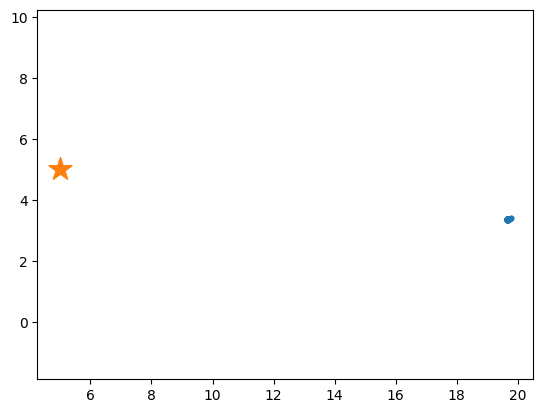

In [51]:
import matplotlib.pyplot as plt

xs = [p.pose[0] for p in particles]
ys = [p.pose[1] for p in particles]

plt.scatter(xs, ys, s=10)

plt.scatter(
    5,
    5,
    marker='*',
    s=300
)

plt.axis('equal')
plt.show()

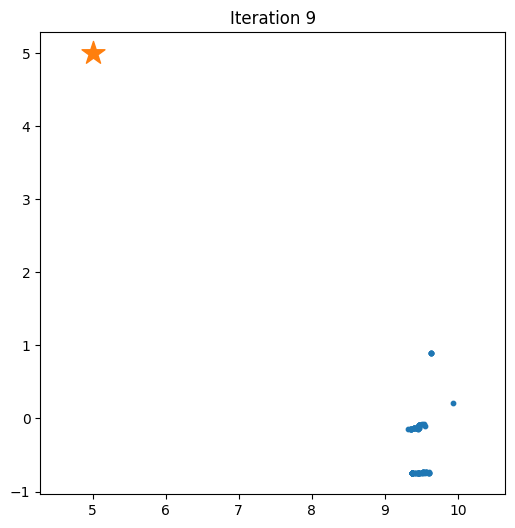

In [ ]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import time

particles = initialize_particles(
    NUM_PARTICLES,
    init_pose
)

for k in range(20):

    particles = fastslam_step(
        particles,
        control,
        measurements,
        dt,
        motion_noise,
        measurement_noise
    )

    clear_output(wait=True)

    plt.figure(figsize=(6,6))

    xs = [p.pose[0] for p in particles]
    ys = [p.pose[1] for p in particles]

    plt.scatter(xs, ys, s=10)

    plt.scatter(
        true_landmark[0],
        true_landmark[1],
        marker='*',
        s=300
    )

    plt.title(f"Iteration {k}")
    plt.axis('equal')

    plt.show()

    time.sleep(1 )